# Projekt 1
### Maciej Flaga

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
from math import sqrt

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBALS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Omówienie metod
## Metoda diagonalizacji
Celem jest rozwiązanie równania Schroedingera niezależnego od czasu w jednym wymiarze w postaci
$$
-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}\psi(x)+V(x)\psi(x)=E\psi(x)
$$ 
W tym celu dyskretyzujemy równanie dzieląc obszar $[-\frac{L}{2}, \frac{L}{2}]$ na N częsci otrzymując wzór na j-ty węzęł 
$$
x_j=-\frac{L}{2}+j\Delta x, \quad j=0,1,...,N
$$
, gdzie $\Delta x=\frac{L}{N}$. Stosując przybliżenie drugiej pochodnej jako centralny iloraz różnicowy 
$$
\frac{d^2\psi}{dx^2}\approx \frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{(\Delta x)^2}
$$
oraz oznaczenie
$$
t = \frac{\hbar^2}{2m(\Delta x)^2}
$$
i wstawiając do równania wyjściowego otrzymujemy
$$
-t\psi_{j+1}+(2t+V_j)\psi_j-t\psi_{j-1}=E\psi_j
$$
Po uwzglęnieniu warunków przegowych w postaci $\psi_0=\psi_N=0$ otrzymujemy problem własny opisany kwadratową macierzą trójdiagonalną
$$
\begin{bmatrix}
2t+V_1 & -t & 0 & \cdots & 0\\
-t & 2t+V_2 & -t & \cdots & 0\\
0 & -t & 2t+V_3 & \cdots & 0\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & -t & 2t+V_{N-1}
\end{bmatrix}
\begin{bmatrix}
\psi_1\\
\psi_2\\
\psi_3\\
\vdots\\
\psi_{N-1}
\end{bmatrix}
=
E
\begin{bmatrix}
\psi_1\\
\psi_2\\
\psi_3\\
\vdots\\
\psi_{N-1}
\end{bmatrix}
$$
który zapiszemy w postaci
$$
\hat{H}\psi_n=E_n\psi_n
$$
Macierz hamiltonianu jest hermitowska co pozwala nam rozwiązać problem korzystając z zoptymalizowanego algorytmu diagonalizacji $\texttt{numpy.linalg.eigh}$. Zaprogramowano funkcję rozwiązującą problem własny dla danego $L, N, V, \hbar, m, k$, gdzie $k$ jest górną liczbą interesujących nas stanów. Funkcja zwraca wartości własne tj. poziomy energii $E_n$; Wektory własne tj. funkcje własne układu $\psi_n$; czas działania algorytmu

In [14]:
def met_diag(L,N,V,hbar,m,k):
    t0 = time.time() # stoper start
    dx=L/N # krok prszestrzenny
    t=hbar**2/(2*m*dx*dx) # parametr t
    H=np.zeros((N-2)**2).reshape((N-2,N-2)) # alokacja hamiltonianu
    for i in range(N-2):
        H[i][i]=2*t+V[i+1] # diagonala
    for i in range(N-3):
        H[i+1][i]=-t # poddiagonala
        H[i][i+1]=-t # naddiagonala
    eigvals, eigvecs = np.linalg.eigh(H) # diagonalizacja
    keigvals = np.zeros(k) # alokacja k pierwszych wartosci wł
    keigvecs = np.zeros(k*(N)).reshape((k,N)) # alokacja k pierwszych wektorów wł

    # print(np.shape(keigvecs))

    for i in range(k):
        keigvals[i] = eigvals[i] # kopiowanie
        keigvecs[i, 1:-1] = eigvecs[i, :] # kopiowanie
    t1=time.time() # stoper stop
    return keigvals, keigvecs, t1-t0

Przyjęto parametry jak poniżej

In [51]:
# parametry
L=5
N=10000
n = [1,3,12,19]
n = np.subtract(n,1)

hbar=1
m=1

dx=L/N

In [52]:
# inicjalizacja
x = np.linspace(-L/2,L/2,N)
V = np.zeros(N)

In [53]:
# diagonalizacja
diag_evals, diag_evecs, diag_czas = met_diag(L,N,V,hbar,m,k=max(n)+1)
print(f'Czas diagonalizacji: {diag_czas:.4f}s')

Czas diagonalizacji: 46.3338s


In [54]:
# normalizacja
norm = 0
for i in range(len(diag_evecs[0])):
    norm += np.abs(diag_evecs[0][i])**2*dx
C = sqrt(1/norm)
diag_evecs=C*diag_evecs

Analityczne funkcje własne opisane wzorem
$$
\psi_n=
\begin{cases}
\sqrt{\frac{2}{L}}\cos{(\frac{n\pi x}{L})}, \quad n \text{ nieparzyste}\\
\sqrt{\frac{2}{L}}\sin{(\frac{n\pi x}{L})}, \quad n \text{ parzyste}
\end{cases}
$$

In [55]:
apsi1 = sqrt(2/L)*np.cos((n[0]+1)*np.pi*x/L)
apsi3 = sqrt(2/L)*np.cos((n[1]+1)*np.pi*x/L)
apsi12 = sqrt(2/L)*np.sin((n[2]+1)*np.pi*x/L)
apsi19 = sqrt(2/L)*np.cos((n[3]+1)*np.pi*x/L)

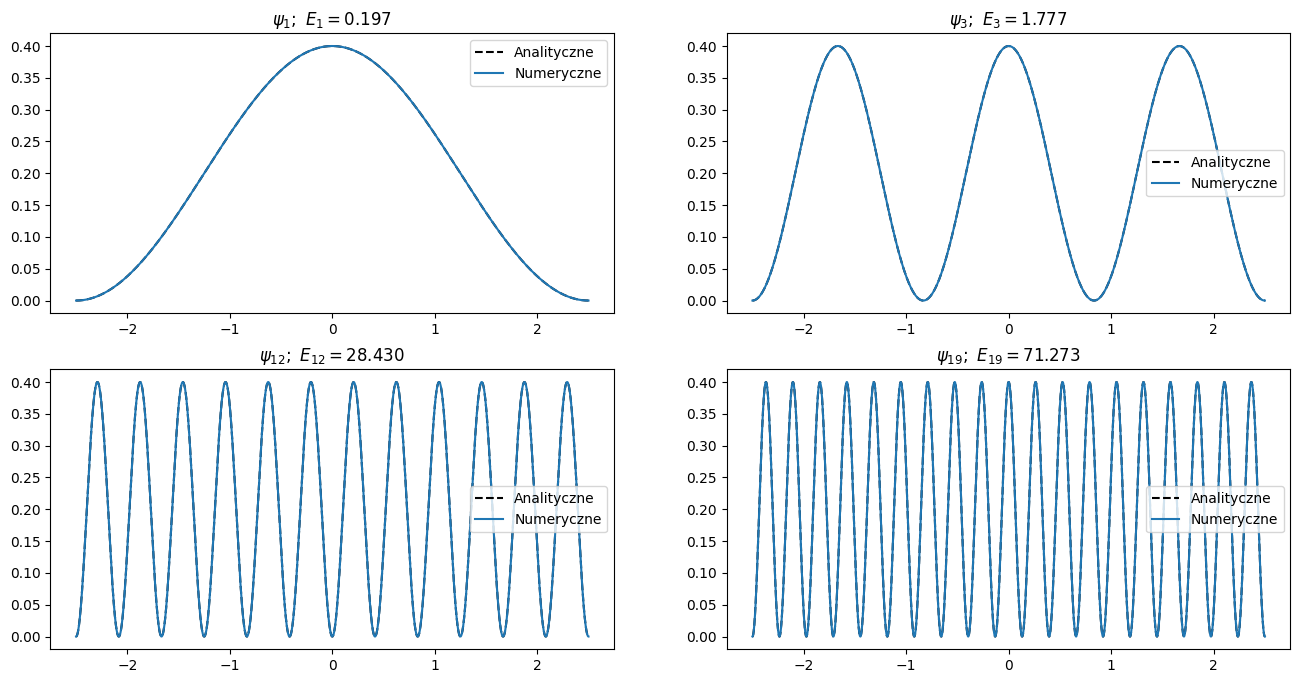

In [56]:
# wykres
fig, axs = plt.subplots(2,2,figsize=(16,8))

k=n[0]
axs[0,0].plot(x,np.abs(apsi1)**2,linestyle='--',color='black', label='Analityczne')
axs[0,0].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[0,0].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[0,0].legend()

k=n[1]
axs[0,1].plot(x,np.abs(apsi3)**2,linestyle='--',color='black', label='Analityczne')
axs[0,1].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[0,1].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[0,1].legend()

k=n[2]
axs[1,0].plot(x,np.abs(apsi12)**2,linestyle='--',color='black', label='Analityczne')
axs[1,0].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[1,0].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[1,0].legend()

k=n[3]
axs[1,1].plot(x,np.abs(apsi19)**2,linestyle='--',color='black', label='Analityczne')
axs[1,1].plot(x,np.abs(diag_evecs[k,:])**2,label='Numeryczne')
axs[1,1].set_title(rf'$\psi_{{{k+1}}};\ E_{{{k+1}}}={diag_evals[k]:.3f}$')
axs[1,1].legend()

# for k in n:
#     plt.plot(x,np.abs(diag_evecs[k,:])**2,label=rf'$E_{{{k+1}}}={diag_evals[k]:.2f}$')
#     plt.legend()
plt.show()

In [57]:
# porównanie
E_analiticzne = np.pi*np.pi*hbar*hbar/(2*m*L*L)*np.pow(np.add(n,1),2)
E_wyznaczone = np.array([diag_evals[n[0]], diag_evals[n[1]], diag_evals[n[2]], diag_evals[n[3]]])
bl_bzw = np.abs(E_analiticzne-E_wyznaczone)
bl_wz = bl_bzw/E_analiticzne
print(f'Energie analityczne:\t{E_analiticzne}')
print(f'Energie numeryczne:\t{E_wyznaczone}')
print(f'Błędy bezwzględne:\t{bl_bzw}')
print(f'Błędy względne:\t\t{bl_wz}')

Energie analityczne:	[ 0.19739209  1.77652879 28.42446068 71.25854378]
Energie numeryczne:	[ 0.19743157  1.77688402 28.43011274 71.27258596]
Błędy bezwzględne:	[3.94816430e-05 3.55226434e-04 5.65206587e-03 1.40421872e-02]
Błędy względne:		[0.00020002 0.00019996 0.00019885 0.00019706]
